In [1]:
import os
import matplotlib.pyplot as plt
from nilearn import plotting, image
import warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
# Change this to the subject you want to check (e.g., '022')
sub = '022' 
ses = '01'

# Define Paths
base_dir = f'/user_data/csimmon2/sym_pt/sub-{sub}/ses-{ses}'
anat_dir = f'{base_dir}/anat'
roi_dir = f'{base_dir}/derivatives/rois'

print(f"Checking Anatomy for: sub-{sub} ses-{ses}")
print(f"Looking in: {base_dir}")

Checking Anatomy for: sub-022 ses-01
Looking in: /user_data/csimmon2/sym_pt/sub-022/ses-01


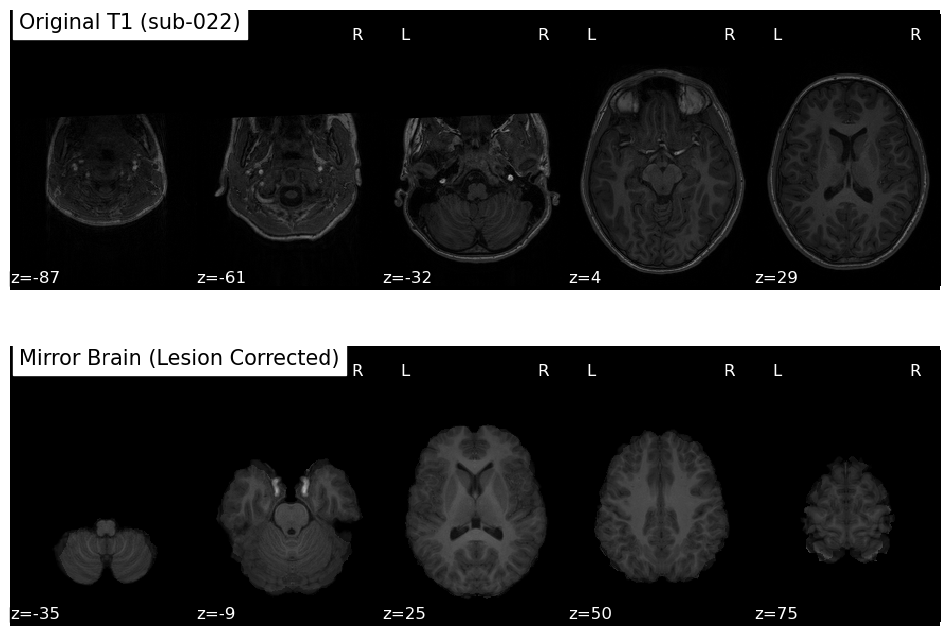

In [2]:
# Load Images
t1_native = f'{anat_dir}/T1w.nii.gz'
t1_mirror = f'{anat_dir}/T1w_mirror.nii.gz'

if os.path.exists(t1_native) and os.path.exists(t1_mirror):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # 1. Original Brain
    plotting.plot_anat(t1_native, title=f"Original T1 (sub-{sub})", 
                       display_mode='z', cut_coords=5, axes=axes[0])
    
    # 2. Mirror Brain (Should look symmetric/healed)
    plotting.plot_anat(t1_mirror, title="Mirror Brain (Lesion Corrected)", 
                       display_mode='z', cut_coords=5, axes=axes[1])
    
    plt.show()
else:
    print("ERROR: Anatomy files not found. Did 03_register_mirror.py run?")

Red: lFFA.nii.gz | Blue: rFFA.nii.gz


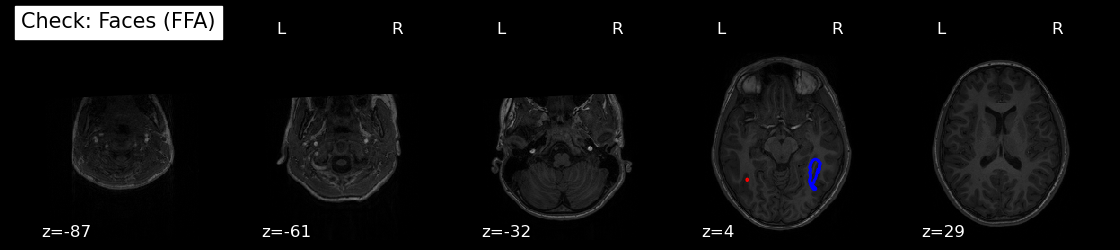

--------------------------------------------------
Red: lPPA.nii.gz | Blue: rPPA.nii.gz


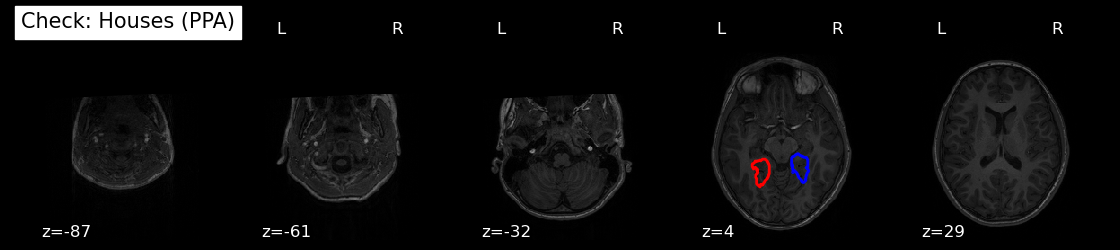

--------------------------------------------------
Red: lLO.nii.gz | Blue: rLO.nii.gz


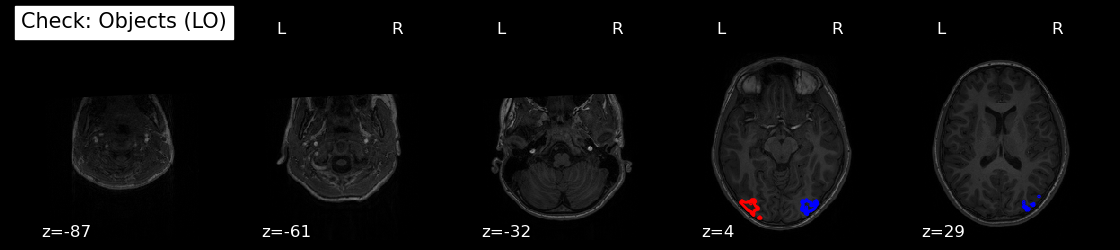

--------------------------------------------------


In [3]:
# Define ROIs to check (Standard Category Selective Regions)
rois_to_plot = [
    ('lFFA.nii.gz', 'rFFA.nii.gz', 'Faces (FFA)'),
    ('lPPA.nii.gz', 'rPPA.nii.gz', 'Houses (PPA)'),
    ('lLO.nii.gz',  'rLO.nii.gz',  'Objects (LO)')
]

# Plotting Loop
for l_roi, r_roi, title in rois_to_plot:
    l_path = f'{roi_dir}/{l_roi}'
    r_path = f'{roi_dir}/{r_roi}'
    
    if os.path.exists(l_path) and os.path.exists(r_path):
        display = plotting.plot_anat(t1_native, title=f"Check: {title}", display_mode='z', cut_coords=5)
        
        # Add Left ROI (Red)
        display.add_contours(l_path, colors='r', linewidths=2, levels=[0.5])
        # Add Right ROI (Blue)
        display.add_contours(r_path, colors='b', linewidths=2, levels=[0.5])
        
        # Add a legend-like note
        print(f"Red: {l_roi} | Blue: {r_roi}")
        plotting.show()
        print("-" * 50)
    else:
        print(f"Skipping {title}: Files not found ({l_roi} or {r_roi})")

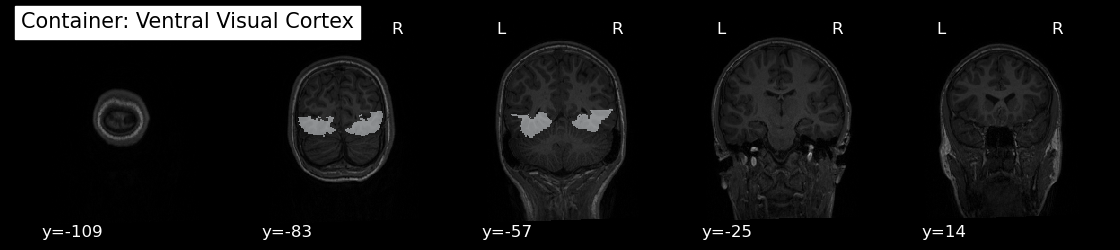

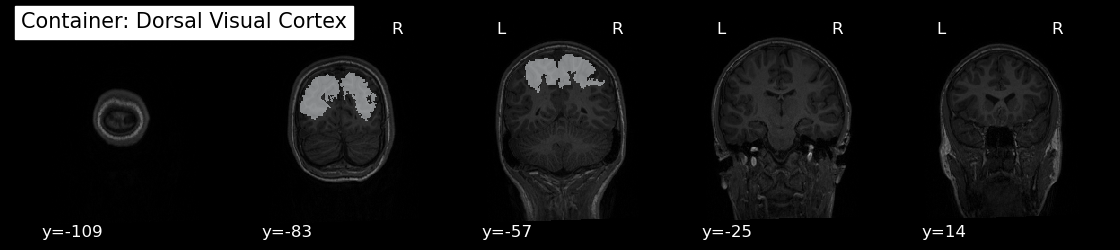

In [4]:
# Define Broad Masks
containers = [
    ('lVentral.nii.gz', 'rVentral.nii.gz', 'Ventral Visual Cortex'),
    ('lDorsal.nii.gz',  'rDorsal.nii.gz',  'Dorsal Visual Cortex')
]

for l_roi, r_roi, title in containers:
    l_path = f'{roi_dir}/{l_roi}'
    r_path = f'{roi_dir}/{r_roi}'
    
    if os.path.exists(l_path) and os.path.exists(r_path):
        # We use cut_coords to show a coronal view (y) to see top/bottom clearly
        display = plotting.plot_anat(t1_native, title=f"Container: {title}", 
                                     display_mode='y', cut_coords=5)
        
        display.add_overlay(l_path, cmap='Reds', alpha=0.5)
        display.add_overlay(r_path, cmap='Blues', alpha=0.5)
        
        plotting.show()
    else:
        print(f"Skipping {title}: Files not found.")